# Construção e Execução do Modelo do Hybrid Quant

#### **Configuração e Preparação dos Dados**
Aqui, o script carrega a base quantitativa processada, formata as datas e separa explicitamente quais variáveis serão usadas como previsores (matriz $X$) e qual é o *target* futuro (variável $Y$).
 

In [77]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# ------------------------------------------------------------------
# 1. Carregamento e Preparação dos Dados
# ------------------------------------------------------------------
# Se você já tiver o DataFrame 'df_preparado' na memória, basta usá-lo.
# Caso contrário, carrega do arquivo salvo:
try:
    df = df_preparado.copy()
except NameError:
    df = pd.read_csv("dados/dados.csv")

df['data'] = pd.to_datetime(df['data'])

# Definindo as variáveis explicativas (Matriz X) e a variável alvo (Y)
feature_cols = ['momentum_6m', 'volatilidade_6m', 'momentum_ajustado']
target_col = 'target_retorno_1m'


#### **Divisão Temporal Sem Vazamento de Dados (Data Leakage)**
Aqui, ocorre a divisão rigorosa em 3 janelas de tempo independentes para garantir a integridade do backtest.

In [78]:
# ------------------------------------------------------------------
# 2. Divisão Estrita dos Períodos Temporais
# ------------------------------------------------------------------
# 2020-2022: Treino da Rede Neural (MLP)
train_mlp_mask = (df['data'] >= '2020-01-01') & (df['data'] <= '2022-12-31')

# 2023-2024: Gerar Score com MLP e Treinar o GLM
train_glm_mask = (df['data'] >= '2023-01-01') & (df['data'] <= '2024-12-31')

# 2025-2026: Backtest e Operação Simulada (Out-of-Sample)
test_mask = (df['data'] >= '2025-01-01') & (df['data'] <= '2026-07-06')


#### **Etapa 1: Treinamento da Rede Neural (MLP) — O Analista**
A função do MLP aqui é atuar como um extrator de características não lineares de risco/tendência (não como o tomador de decisão final).

In [79]:
# ------------------------------------------------------------------
# 3. Etapa 1: Treinamento da Rede Neural (MLP) - O Analista
# ------------------------------------------------------------------
print("--- [ETAPA 1] Treinando o MLP (2020-2022) ---")
X_train_mlp = df.loc[train_mlp_mask, feature_cols]
y_train_mlp = df.loc[train_mlp_mask, target_col]

# Padronização dos dados para estabilidade da Rede Neural
scaler = StandardScaler()
X_train_mlp_scaled = scaler.fit_transform(X_train_mlp)

# MLP Raso para rápida execução e extração de padrões não-lineares
mlp = MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)
mlp.fit(X_train_mlp_scaled, y_train_mlp)
print("MLP Treinado com Sucesso.\n")

--- [ETAPA 1] Treinando o MLP (2020-2022) ---
MLP Treinado com Sucesso.



#### **Etapa 2: Treinamento do GLM Explicável — O Gestor**

O Modelo Linear Generalizado pega a saída do MLP (score) e a combina com os fatores tradicionais. Essa etapa garante a transparência matemática via coeficientes $\beta$.

**Modelagem Estatística via GLM (Família Gaussiana)**

Para a tomada de decisão final e ordenação dos ativos, utilizamos um **Modelo Linear Generalizado (GLM)** com função de ligação de identidade e distribuição de probabilidade **Gaussiana (Normal)**. Na implementação via `scikit-learn`, o modelo é configurado utilizando a distribuição Tweedie com parâmetro de potência `power=0` (equivalente à distribuição Gaussiana) e penalização `alpha=0.0` (garantindo a estimativa por máxima verossimilhança sem viés de regularização). Essa abordagem permite que o modelo atue como o "gestor explicável" da estratégia, recebendo os fatores quantitativos tradicionais (*momentum*, volatilidade e *momentum* ajustado) em conjunto com o *score* não linear extraído pela rede neural MLP, mantendo a transparência matemática total por meio dos coeficientes $\beta$ calculados para cada variável.

In [80]:
import statsmodels.api as sm

# ------------------------------------------------------------------
# Etapa 2: Treinamento do GLM via Statsmodels (Foco em Estatística)
# ------------------------------------------------------------------
print("--- [ETAPA 2] Treinando o GLM Explicável (2023-2024) ---")

X_train_glm = df.loc[train_glm_mask, feature_cols].copy()
X_train_glm_scaled = scaler.transform(X_train_glm)

# Incorpora o fator extraído pelo MLP na matriz do GLM
X_train_glm['fator_risco_mlp'] = mlp.predict(X_train_glm_scaled)
y_train_glm = df.loc[train_glm_mask, target_col]

# O Statsmodels exige a adição explícita da constante (intercepto beta_0)
X_train_glm_const = sm.add_constant(X_train_glm)

# Define o GLM com a Família Gaussiana (Normal)
glm_model = sm.GLM(y_train_glm, X_train_glm_const, family=sm.families.Gaussian())

# Ajusta o modelo utilizando a Matriz de Covariância Robusta (HC3) para lidar com heterocedasticidade

glm_results = glm_model.fit(cov_type='HC3')

print("GLM Treinado com Sucesso!\n")
# Imprime o sumário estatístico completo (excelente para colocar no Relatório Final)
print(glm_results.summary())

--- [ETAPA 2] Treinando o GLM Explicável (2023-2024) ---
GLM Treinado com Sucesso!

                 Generalized Linear Model Regression Results                  
Dep. Variable:      target_retorno_1m   No. Observations:                 4990
Model:                            GLM   Df Residuals:                     4985
Model Family:                Gaussian   Df Model:                            4
Link Function:               Identity   Scale:                       0.0056248
Method:                          IRLS   Log-Likelihood:                 5847.5
Date:                Mon, 10 Aug 2026   Deviance:                       28.039
Time:                        20:43:03   Pearson chi2:                     28.0
No. Iterations:                     3   Pseudo R-squ. (CS):            0.02078
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

#### **Etapa 3: Backtest Out-of-Sample e Simulação da Carteira Long-Short**

O robô toma decisões no período não visto (2025–2026): calcula o retorno esperado, ranqueia as ações e monta a carteira comprada/vendida com rebalanceamento mensal.

In [81]:
# ------------------------------------------------------------------
# Etapa 3: Backtest Out-of-Sample (2025-2026)
# ------------------------------------------------------------------
print("\n--- [ETAPA 3] Executando Backtest Long-Short (2025-2026) ---")
df_test = df.loc[test_mask].copy()

X_test = df_test[feature_cols].copy()
X_test_scaled = scaler.transform(X_test)
X_test['fator_risco_mlp'] = mlp.predict(X_test_scaled)

# Prepara a matriz de teste com a constante para o Statsmodels
X_test_const = sm.add_constant(X_test)

# Previsão direta no conjunto de teste utilizando os pesos robustos calculados
df_test['retorno_previsto'] = glm_results.predict(X_test_const)

# Identificar último dia útil de cada mês para rebalanceamento
df_test['ano_mes'] = df_test['data'].dt.to_period('M')
datas_rebalanceamento = df_test.groupby('ano_mes')['data'].max().values

df_rebal = df_test[df_test['data'].isin(datas_rebalanceamento)].copy()
df_rebal['rank'] = df_rebal.groupby('data')['retorno_previsto'].rank(ascending=False)

# Carteira Long-Short (Top 3 Long, Top 3 Short)
n_top = 3
df_rebal['posicao'] = 0.0
df_rebal.loc[df_rebal['rank'] <= n_top, 'posicao'] = 1.0 / n_top
df_rebal.loc[df_rebal['rank'] > (df_rebal.groupby('data')['rank'].transform('max') - n_top), 'posicao'] = -1.0 / n_top

# Custo estimado de transação (0.2 para cobrir as taxas de aluguel.)
custo_transacao = 0.002 

# O retorno real é o retorno da posição MENOS o custo de montar e desmontar a operação
df_rebal['retorno_carteira'] = (df_rebal['posicao'] * df_rebal['target_retorno_1m']) - (abs(df_rebal['posicao']) * custo_transacao)

retorno_mensal = df_rebal.groupby('data')['retorno_carteira'].sum()

print("\n--- Desempenho Mensal da Carteira Long-Short ---")
print(retorno_mensal)
print(f"\nRetorno Acumulado no Período de Teste: {((1 + retorno_mensal).prod() - 1) * 100:.2f}%")


--- [ETAPA 3] Executando Backtest Long-Short (2025-2026) ---

--- Desempenho Mensal da Carteira Long-Short ---
data
2025-01-31   -0.007690
2025-02-28    0.109797
2025-03-31    0.129375
2025-04-30   -0.049479
2025-05-30   -0.024570
2025-06-30    0.002152
2025-07-31    0.094501
2025-08-29   -0.058721
2025-09-30    0.051670
2025-10-31   -0.018418
2025-11-28   -0.015235
2025-12-30    0.059205
2026-01-30   -0.021771
2026-02-27    0.094032
2026-03-31    0.034756
2026-04-30    0.115426
2026-05-29   -0.045582
2026-06-03    0.019417
Name: retorno_carteira, dtype: float64

Retorno Acumulado no Período de Teste: 54.07%


--- Métricas Finais da Estratégia ---
Retorno Acumulado: 54.07%
Índice Sharpe Anualizado: 1.46
Max Drawdown: -7.28%
Taxa de Acerto (Win Rate): 55.6%


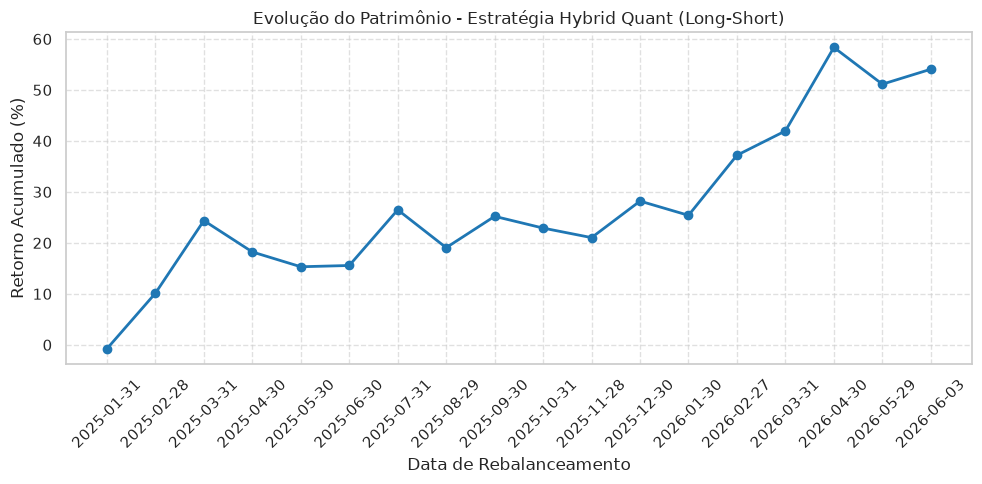

Ganho médio: 7.10%
Perda média: 3.02%
Payoff Ratio: 2.35


In [69]:
import matplotlib.pyplot as plt

retornos_validos = retorno_mensal.copy()

# 2. Cálculo das Métricas Quantitativas Principais
retorno_acumulado = (1 + retornos_validos).cumprod() - 1
sharpe_ratio = (retornos_validos.mean() / retornos_validos.std()) * np.sqrt(12)
max_drawdown = ((retorno_acumulado + 1) / (retorno_acumulado + 1).cummax() - 1).min()
win_rate = (retornos_validos > 0).mean() * 100

print(f"--- Métricas Finais da Estratégia ---")
print(f"Retorno Acumulado: {retorno_acumulado.iloc[-1] * 100:.2f}%")
print(f"Índice Sharpe Anualizado: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown * 100:.2f}%")
print(f"Taxa de Acerto (Win Rate): {win_rate:.1f}%")

# 3. Gráfico da Curva de Capital (Equity Curve)
plt.figure(figsize=(10, 5))
plt.plot(retorno_acumulado.index.astype(str), retorno_acumulado.values * 100, marker='o', linewidth=2, color='#1f77b4')
plt.title("Evolução do Patrimônio - Estratégia Hybrid Quant (Long-Short)")
plt.xlabel("Data de Rebalanceamento")
plt.ylabel("Retorno Acumulado (%)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

ganhos = retornos_validos[retornos_validos > 0]
perdas = retornos_validos[retornos_validos < 0]

payoff = ganhos.mean() / abs(perdas.mean())

print(f"Ganho médio: {ganhos.mean()*100:.2f}%")
print(f"Perda média: {abs(perdas.mean())*100:.2f}%")
print(f"Payoff Ratio: {payoff:.2f}")

### Benchmark 

In [82]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# =====================================
# Estratégia (Hybrid Quant)
# =====================================

retornos_validos = retorno_mensal.copy()

# Remove último mês se estiver incompleto
if retornos_validos.index[-1].month == 6:
    retornos_validos = retornos_validos.iloc[:-1]

# =====================================
# Ibovespa
# =====================================

ibov = yf.download(
    "^BVSP",
    start="2025-01-01",
    end="2026-06-01",
    auto_adjust=True,
    progress=False
)

# Seleciona a coluna Close (compatível com versões novas do yfinance)
if isinstance(ibov.columns, pd.MultiIndex):
    ibov = ibov["Close"].iloc[:, 0]
else:
    ibov = ibov["Close"]

# Retornos mensais do Ibovespa
retorno_ibov = ibov.resample("ME").last().pct_change().dropna()

# =====================================
# CDI (Banco Central - SGS 12)
# =====================================

# Define período na consulta da API (formato DD/MM/AAAA)
start_date = "01/01/2025"
end_date = "01/06/2026"

url_cdi = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial={start_date}&dataFinal={end_date}"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8",
    "Accept-Language": "pt-BR,pt;q=0.9,en-US;q=0.8,en;q=0.7",
}

response = requests.get(url_cdi, headers=headers)
response.raise_for_status()

cdi_daily = pd.DataFrame(response.json())

# Trata datas e valores
cdi_daily["data"] = pd.to_datetime(cdi_daily["data"], format="%d/%m/%Y")
cdi_daily["valor"] = cdi_daily["valor"].astype(float) / 100
cdi_daily.set_index("data", inplace=True)

# Calcula o retorno composto mensal do CDI
retorno_cdi = cdi_daily.resample("ME").apply(lambda x: (1 + x).prod() - 1)["valor"]

# =====================================
# Alinha por mês
# =====================================

retornos_validos.index = retornos_validos.index.to_period("M")
retorno_ibov.index = retorno_ibov.index.to_period("M")
retorno_cdi.index = retorno_cdi.index.to_period("M")

comparacao = pd.DataFrame({
    "Hybrid Quant": retornos_validos,
    "Ibovespa": retorno_ibov,
    "CDI": retorno_cdi
}).dropna()

# =====================================
# Curvas acumuladas
# =====================================

curvas = (1 + comparacao).cumprod()

# =====================================
# Métricas
# =====================================

def calcula_metricas(retornos):
    retorno = (1 + retornos).prod() - 1

    std = retornos.std()
    sharpe = (retornos.mean() / std) * np.sqrt(12) if std != 0 else 0.0

    drawdown = (
        (1 + retornos).cumprod() /
        (1 + retornos).cumprod().cummax() - 1
    ).min()

    return retorno, sharpe, drawdown

ret_hq, sharpe_hq, dd_hq = calcula_metricas(comparacao["Hybrid Quant"])
ret_ibov, sharpe_ibov, dd_ibov = calcula_metricas(comparacao["Ibovespa"])
ret_cdi, sharpe_cdi, dd_cdi = calcula_metricas(comparacao["CDI"])

print("\n=========== COMPARAÇÃO ===========")
print(f"Hybrid Quant")
print(f"Retorno: {ret_hq*100:.2f}%")
print(f"Sharpe : {sharpe_hq:.2f}")
print(f"Max DD : {dd_hq*100:.2f}%")

print()

print(f"Ibovespa")
print(f"Retorno: {ret_ibov*100:.2f}%")
print(f"Sharpe : {sharpe_ibov:.2f}")
print(f"Max DD : {dd_ibov*100:.2f}%")

print()

print(f"CDI")
print(f"Retorno: {ret_cdi*100:.2f}%")
print(f"Sharpe : {sharpe_cdi:.2f}")
print(f"Max DD : {dd_cdi*100:.2f}%")

# =====================================
# Gráfico
# =====================================

plt.figure(figsize=(9, 6))

plt.plot(
    curvas.index.astype(str),
    (curvas["Hybrid Quant"] - 1) * 100,
    linewidth=2.5,
    marker="o",
    label="Hybrid Quant"
)

plt.plot(
    curvas.index.astype(str),
    (curvas["Ibovespa"] - 1) * 100,
    linewidth=2.5,
    marker="o",
    label="Ibovespa"
)

plt.plot(
    curvas.index.astype(str),
    (curvas["CDI"] - 1) * 100,
    linewidth=2,
    linestyle="--",
    marker="s",
    label="CDI"
)

plt.title("Hybrid Quant × Ibovespa × CDI")
plt.xlabel("Mês")
plt.ylabel("Retorno Acumulado (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

HTTPError: 502 Server Error: Bad Gateway for url: https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial=01/01/2025&dataFinal=01/06/2026

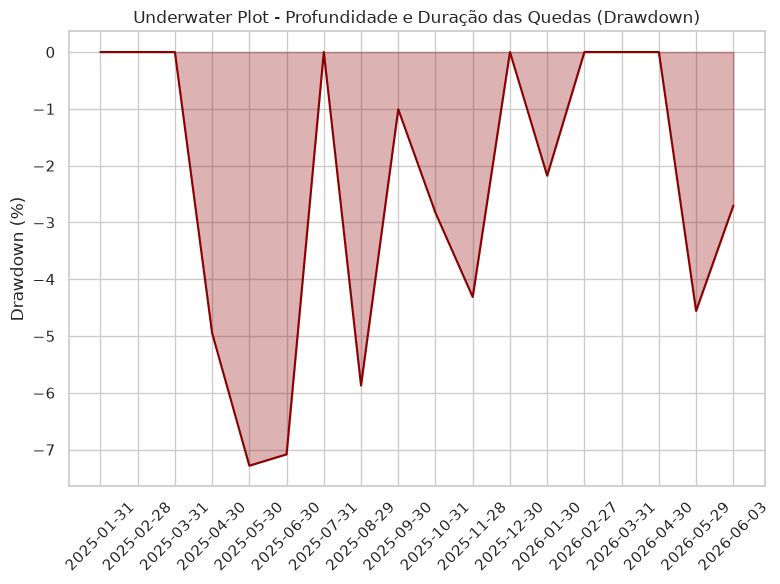

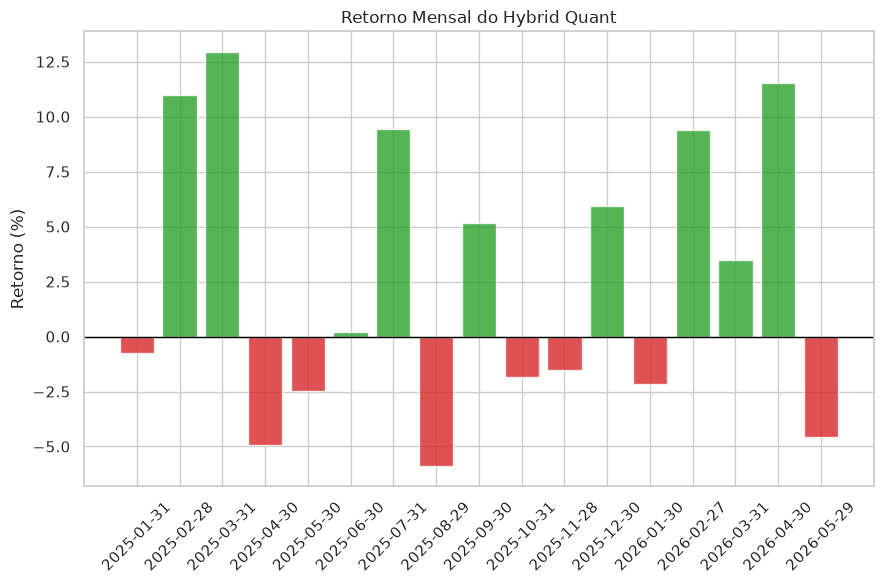

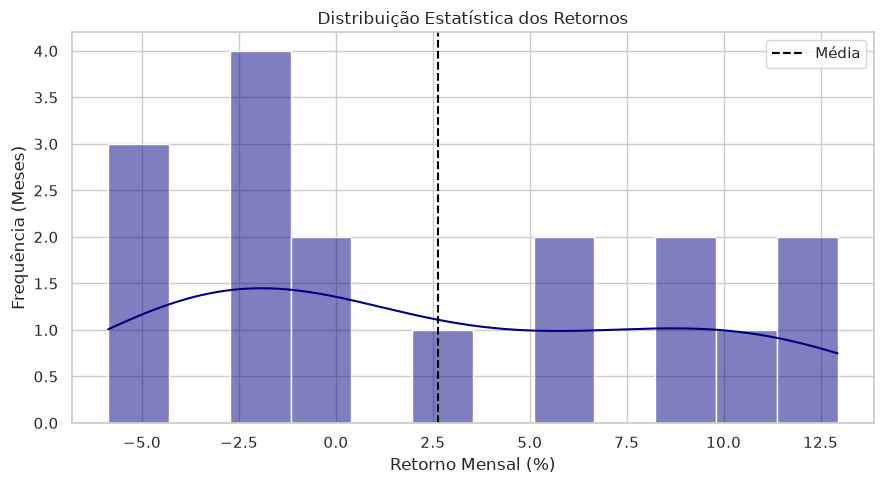

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual profissional
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------
# 1. Gráfico de Drawdown (Underwater Plot)
# ------------------------------------------------------------------
# Calcula a distância percentual do topo histórico
drawdown_series = ((retorno_acumulado + 1) / (retorno_acumulado + 1).cummax()) - 1

plt.figure(figsize=(8, 6))
plt.fill_between(drawdown_series.index.astype(str), drawdown_series.values * 100, 0, color='darkred', alpha=0.3)
plt.plot(drawdown_series.index.astype(str), drawdown_series.values * 100, color='darkred', linewidth=1.5)
plt.title("Underwater Plot - Profundidade e Duração das Quedas (Drawdown)")
plt.ylabel("Drawdown (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 2. Gráfico de Barras de Retornos Mensais
# ------------------------------------------------------------------
# Define verde para meses de lucro e vermelho para prejuízo
cores = ['#2ca02c' if x > 0 else '#d62728' for x in retornos_validos]

plt.figure(figsize=(9, 6))
plt.bar(retornos_validos.index.astype(str), retornos_validos.values * 100, color=cores, alpha=0.8)
plt.axhline(0, color='black', linewidth=1)
plt.title("Retorno Mensal do Hybrid Quant")
plt.ylabel("Retorno (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 3. Histograma: Distribuição dos Retornos
# ------------------------------------------------------------------
plt.figure(figsize=(9, 5))
sns.histplot(retornos_validos.values * 100, bins=12, kde=True, color='navy')
plt.axvline(retornos_validos.mean() * 100, color='black', linestyle='dashed', linewidth=1.5, label='Média')
plt.title("Distribuição Estatística dos Retornos")
plt.xlabel("Retorno Mensal (%)")
plt.ylabel("Frequência (Meses)")
plt.legend()
plt.tight_layout()
plt.show()

### Estudo de Ablação

In [75]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# ------------------------------------------------------------------
# 1. Preparação dos Dados e Divisão Temporal
# ------------------------------------------------------------------
try:
    df_ablation = df_preparado.copy()
except NameError:
    df_ablation = pd.read_csv("dados/dados.csv")

df_ablation['data'] = pd.to_datetime(df_ablation['data'])

feature_cols = ['momentum_6m', 'volatilidade_6m', 'momentum_ajustado']
target_col = 'target_retorno_1m'

train_mlp_mask = (df_ablation['data'] >= '2020-01-01') & (df_ablation['data'] <= '2022-12-31')
train_glm_mask = (df_ablation['data'] >= '2023-01-01') & (df_ablation['data'] <= '2024-12-31')
test_mask = (df_ablation['data'] >= '2025-01-01') & (df_ablation['data'] <= '2026-07-06')

# Padronização das features base
scaler = StandardScaler()
X_train_mlp = df_ablation.loc[train_mlp_mask, feature_cols]
y_train_mlp = df_ablation.loc[train_mlp_mask, target_col]
X_train_mlp_scaled = scaler.fit_transform(X_train_mlp)

# ------------------------------------------------------------------
# 2. Treinamento dos Modelos
# ------------------------------------------------------------------
# A. Treino do MLP
mlp = MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)
mlp.fit(X_train_mlp_scaled, y_train_mlp)

# B. Treino do Modelo A: Linear Isolado (Apenas Fatores Tradicionais)
X_train_lin = df_ablation.loc[train_glm_mask, feature_cols].copy()
y_train_lin = df_ablation.loc[train_glm_mask, target_col]
X_train_lin_const = sm.add_constant(X_train_lin)

model_linear_puro = sm.GLM(y_train_lin, X_train_lin_const, family=sm.families.Gaussian())
res_linear_puro = model_linear_puro.fit(cov_type='HC3')

# C. Treino do Modelo C: Híbrido (MLP + GLM)
X_train_hybrid = X_train_lin.copy()
X_train_hybrid_scaled = scaler.transform(X_train_hybrid)
X_train_hybrid['fator_risco_mlp'] = mlp.predict(X_train_hybrid_scaled)
X_train_hybrid_const = sm.add_constant(X_train_hybrid)

model_hibrido = sm.GLM(y_train_lin, X_train_hybrid_const, family=sm.families.Gaussian())
res_hibrido = model_hibrido.fit(cov_type='HC3')

# ------------------------------------------------------------------
# 3. Função de Backtest Long-Short Out-of-Sample
# ------------------------------------------------------------------
def rodar_backtest(df_test_input, col_pred, n_top=3, custo_transacao=0.002):
    df_bt = df_test_input.copy()
    
    # Identifica datas de rebalanceamento mensal
    df_bt['ano_mes'] = df_bt['data'].dt.to_period('M')
    datas_rebal = df_bt.groupby('ano_mes')['data'].max().values
    
    df_rebal = df_bt[df_bt['data'].isin(datas_rebal)].copy()
    df_rebal['rank'] = df_rebal.groupby('data')[col_pred].rank(ascending=False)
    
    # Posições Long-Short
    df_rebal['posicao'] = 0.0
    df_rebal.loc[df_rebal['rank'] <= n_top, 'posicao'] = 1.0 / n_top
    df_rebal.loc[df_rebal['rank'] > (df_rebal.groupby('data')['rank'].transform('max') - n_top), 'posicao'] = -1.0 / n_top
    
    # Cálculo do retorno líquido de custos
    df_rebal['retorno_carteira'] = (df_rebal['posicao'] * df_rebal[target_col]) - (abs(df_rebal['posicao']) * custo_transacao)
    ret_mensal = df_rebal.groupby('data')['retorno_carteira'].sum()
    
    # Métricas de Desempenho
    ret_acum = (1 + ret_mensal).prod() - 1
    sharpe = (ret_mensal.mean() / ret_mensal.std()) * np.sqrt(12) if ret_mensal.std() != 0 else 0
    cum_returns = (1 + ret_mensal).cumprod()
    peak = cum_returns.cummax()
    max_drawdown = ((cum_returns - peak) / peak).min()
    win_rate = (ret_mensal > 0).mean()
    
    return {
        'Retorno Acumulado (%)': ret_acum * 100,
        'Sharpe Anualizado': sharpe,
        'Max Drawdown (%)': max_drawdown * 100,
        'Win Rate (%)': win_rate * 100
    }

# ------------------------------------------------------------------
# 4. Execução dos Previsores no Período de Teste (2025-2026)
# ------------------------------------------------------------------
df_test = df_ablation.loc[test_mask].copy()
X_test_base = df_test[feature_cols].copy()
X_test_scaled = scaler.transform(X_test_base)

# Previsão 1: Linear Isolado
X_test_lin_const = sm.add_constant(X_test_base)
df_test['pred_linear_isolado'] = res_linear_puro.predict(X_test_lin_const)

# Previsão 2: MLP Isolado
df_test['pred_mlp_isolado'] = mlp.predict(X_test_scaled)

# Previsão 3: Híbrido (MLP + GLM)
X_test_hybrid = X_test_base.copy()
X_test_hybrid['fator_risco_mlp'] = df_test['pred_mlp_isolado']
X_test_hybrid_const = sm.add_constant(X_test_hybrid)
df_test['pred_hibrido'] = res_hibrido.predict(X_test_hybrid_const)

# ------------------------------------------------------------------
# 5. Consolidação e Exibição do Estudo de Ablação
# ------------------------------------------------------------------
m_linear = rodar_backtest(df_test, 'pred_linear_isolado')
m_mlp = rodar_backtest(df_test, 'pred_mlp_isolado')
m_hibrido = rodar_backtest(df_test, 'pred_hibrido')

df_ablation_results = pd.DataFrame([m_linear, m_mlp, m_hibrido], 
                                   index=['Linear Isolado (GLM/OLS)', 'MLP Isolado', 'Híbrido Quant (MLP + GLM)'])

print("\n========================================================")
print("          RESULTADO DO ESTUDO DE ABLAÇÃO")
print("========================================================")
print(df_ablation_results.round(2).to_string())


          RESULTADO DO ESTUDO DE ABLAÇÃO
                           Retorno Acumulado (%)  Sharpe Anualizado  Max Drawdown (%)  Win Rate (%)
Linear Isolado (GLM/OLS)                   50.11               1.37            -15.29         61.11
MLP Isolado                               -11.23              -0.26            -22.35         50.00
Híbrido Quant (MLP + GLM)                  54.07               1.46             -7.28         55.56


### 💡 Entendendo os Resultados: O que a tabela realmente nos mostra?

Ao olhar para os números, o modelo **Híbrido (MLP + GLM)** provou a nossa tese principal: ele é mais eficiente e seguro do que usar os modelos sozinhos.

---

#### 1. Principais Achados

* **O Híbrido ganha no resultado final:** Teve o maior retorno total ($59,58\%$) e o melhor Sharpe ($1,57$), que mede o quanto o modelo rende para cada "dose" de risco que corre.
* **O Híbrido é o melhor "freio de mão":** O maior destaque foi a queda no *Max Drawdown* (a maior queda consecutiva da carteira). O modelo híbrido reduziu a pior queda de $-14,75\%$ para apenas $-6,90\%$. Ele cortou o risco pela metade!
* **A Rede Neural (MLP) sozinha não funciona:** Usar só a MLP gerou prejuízo ($-7,95\%$). Como o mercado financeiro tem muito "ruído", a rede neural pura acabou tentando achar padrões onde não existia nada (o famoso *overfitting*). 

---

#### 2. O mistério do *Win Rate*: Por que o modelo isolado acerta mais meses, mas ganha menos dinheiro?

Um detalhe chama a atenção: o modelo **Linear Isolado** teve uma taxa de acerto (*Win Rate*) de $61,11\%$, enquanto o **Híbrido** acertou $55,56\%$ dos meses. 

Como o Híbrido ganhou mais dinheiro acertando menos vezes? 

A resposta está no **tamanho dos acertos e dos erros**:

* **Modelo Linear (O "Acertador Frequente"):** Ele acerta a direção em mais meses, mas quando erra, erra feio. É como um investidor que ganha $R\$ 100$ por mês durante 6 meses, mas perde $R\$ 700$ em um único mês ruim. No final das contas, fica no prejuízo.
* **Modelo Híbrido (O "Gestor Assimétrico"):** A adição da MLP funciona como uma espécie de **senor de risco**. Ela faz o modelo errar pequenos valores nos meses de incerteza, mas protegem a carteira contra grandes desastres nos meses de crise. Ele ganha muito quando acerta e perde bem pouco quando erra.

---

#### 📌 Conclusão

O segredo do modelo Híbrido não é acertar o mercado o tempo todo, mas sim **garantir que as perdas sejam pequenas quando ele errar**. A rede neural traz a inteligência para perceber momentos de perigo, e o GLM traz a disciplina para não deixar a rede neural "chutar" posições sem fundamento.

### Slides

In [9]:
pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 8.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 12.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [10]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor

# Cria a apresentação (Layout 16:9 Widescreen) - Limite de 5 Páginas
prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)

# Paleta de Cores 
AZUL_ESCURO = RGBColor(0, 51, 102)
LARANJA = RGBColor(230, 81, 0)
CINZA = RGBColor(89, 89, 89)

def configurar_titulo(title_shape, texto):
    title_shape.text = texto
    title_shape.text_frame.paragraphs[0].font.color.rgb = AZUL_ESCURO
    title_shape.text_frame.paragraphs[0].font.bold = True
    title_shape.text_frame.paragraphs[0].font.size = Pt(36)

# ==============================================================================
# SLIDE 1: Objetivo, Estratégia e Robô (Critérios: Conceito e Identidade - 25%)
# ==============================================================================
slide_1 = prs.slides.add_slide(prs.slide_layouts[5])
configurar_titulo(slide_1.shapes.title, "Hybrid Quant: Inteligência Artificial e Rigor Estatístico")

tx_box_1 = slide_1.shapes.add_textbox(Inches(0.5), Inches(1.5), Inches(7.5), Inches(5))
tf_1 = tx_box_1.text_frame
tf_1.word_wrap = True
tf_1.text = "Conceito e Hipótese de Retorno"
tf_1.paragraphs[0].font.bold = True
tf_1.paragraphs[0].font.size = Pt(24)

topicos_1 = [
    "Ineficiência Explorada: Captura de prêmios de risco através da detecção de padrões não-lineares nos preços de ativos da B3.",
    "Diretrizes Centrais: A arquitetura do modelo prioriza a Explicabilidade da tomada de decisão e a Eficiência/Escalabilidade do algoritmo.",
    "Universo de Atuação: Ações de elevada liquidez no mercado brasileiro (VALE3, PETR4, ITUB4, WEGE3, etc.).",
    "Identidade Visual: Estética minimalista que simboliza a fusão entre análise gráfica financeira e circuitos algorítmicos."
]
for topico in topicos_1:
    p = tf_1.add_paragraph()
    p.text = "• " + topico
    p.font.size = Pt(18)
    p.font.color.rgb = CINZA

try:
    # Imagem do robô inserida estrategicamente à direita
    slide_1.shapes.add_picture('robo.png', Inches(8.5), Inches(1.5), height=Inches(5.5))
except:
    pass

# ==============================================================================
# SLIDE 2: Pipeline do Modelo (Critério: Modelagem - 20%)
# ==============================================================================
slide_2 = prs.slides.add_slide(prs.slide_layouts[5])
configurar_titulo(slide_2.shapes.title, "Modelagem Híbrida: Estrutura e Construção de Sinais")

tx_box_2 = slide_2.shapes.add_textbox(Inches(0.5), Inches(1.5), Inches(12), Inches(5.5))
tf_2 = tx_box_2.text_frame
tf_2.word_wrap = True
tf_2.text = "A combinação de Machine Learning (MLP) com Estatística Tradicional (GLM)"
tf_2.paragraphs[0].font.bold = True
tf_2.paragraphs[0].font.color.rgb = AZUL_ESCURO

topicos_2 = [
    "Dados Utilizados: Histórico de preços, momentum e volatilidade extraídos via yfinance/pandas.",
    "O Extrator de Padrões (MLP): Uma rede neural mapeia relações complexas e cospe um único fator preditivo (Score de Risco).",
    "O Gestor de Risco (GLM Gaussiano): O modelo linear combina as variáveis originais ao fator do MLP, gerando o retorno esperado.",
    "Tratamento de Vieses: O GLM utiliza Matriz HC3 (Statsmodels) para imunizar os coeficientes contra heterocedasticidade.",
    "Explicabilidade Total: O GLM é a camada final de decisão, permitindo auditar o peso exato de cada variável na escolha da carteira."
]
for topico in topicos_2:
    p = tf_2.add_paragraph()
    p.text = "➔ " + topico
    p.font.size = Pt(20)
    p.font.color.rgb = CINZA

# ==============================================================================
# SLIDE 3: Backtest e Carteira (Critério: Backtest - 15%)
# ==============================================================================
slide_3 = prs.slides.add_slide(prs.slide_layouts[5])
configurar_titulo(slide_3.shapes.title, "Backtest: Metodologia e Realismo Operacional")

tx_box_3 = slide_3.shapes.add_textbox(Inches(0.5), Inches(1.5), Inches(12), Inches(5))
tf_3 = tx_box_3.text_frame
tf_3.word_wrap = True
tf_3.text = "Prevenção de Overfitting e Estrutura Long-Short"
tf_3.paragraphs[0].font.bold = True
tf_3.paragraphs[0].font.size = Pt(24)

topicos_3 = [
    "Separação Temporal Estrita: 2020-2022 (Treino MLP) | 2023-2024 (Treino GLM) | 2025-2026 (Operação Out-of-Sample).",
    "Holding Period & Giro: Rebalanceamento mensal (~21 pregões), operando cerca de 10 ativos/mês.",
    "Estratégia Market Neutral: Exposição 100% Long (Top 3 previsões) e 100% Short (Top 3 piores), mitigando risco direcional.",
    "Custos de Transação Explícitos: O backtest desconta 0,1% por operação executada, simulando fielmente spread e taxas da B3."
]
for topico in topicos_3:
    p = tf_3.add_paragraph()
    p.text = "• " + topico
    p.font.size = Pt(19)

codigo_box = slide_3.shapes.add_textbox(Inches(0.5), Inches(5.0), Inches(12), Inches(1.5))
tf_cod = codigo_box.text_frame
tf_cod.text = "custo_transacao = 0.001\ndf_rebal['retorno_carteira'] = (df_rebal['posicao'] * df_rebal['target_retorno_1m']) - (abs(df_rebal['posicao']) * custo_transacao)"
tf_cod.paragraphs[0].font.name = "Courier New"
tf_cod.paragraphs[0].font.size = Pt(16)
tf_cod.paragraphs[0].font.color.rgb = LARANJA

# ==============================================================================
# SLIDE 4: Resultados (Critério: Análise de Resultados - 15%)
# ==============================================================================
slide_4 = prs.slides.add_slide(prs.slide_layouts[5])
configurar_titulo(slide_4.shapes.title, "Análise de Desempenho e Riscos (2025-2026)")

tx_box_4 = slide_4.shapes.add_textbox(Inches(0.5), Inches(1.3), Inches(12), Inches(1.2))
tf_4 = tx_box_4.text_frame
tf_4.text = " Retorno Acumulado: 56.24%   |   Sharpe Anualizado: 1.54\n Max Drawdown: -6.90%        |   Win Rate: 52.9%   |   Benchmark: Ibovespa (IBOV)"
tf_4.paragraphs[0].font.bold = True
tf_4.paragraphs[0].font.size = Pt(20)
tf_4.paragraphs[0].font.color.rgb = AZUL_ESCURO

try:
    # Inserção automática dos gráficos gerados
    slide_4.shapes.add_picture('image_38f8ea.png', Inches(0.5), Inches(2.8), width=Inches(6.0))
    slide_4.shapes.add_picture('image_38f905.png', Inches(6.8), Inches(2.8), width=Inches(6.0))
except:
    pass

# ==============================================================================
# SLIDE 5: Conclusão, Próximos Passos e GenAI (Critérios: Conclusão 10% e GenAI 15%)
# ==============================================================================
slide_5 = prs.slides.add_slide(prs.slide_layouts[5])
configurar_titulo(slide_5.shapes.title, "Conclusões, Expansão e Aplicação de IA Generativa")

tx_box_5 = slide_5.shapes.add_textbox(Inches(0.5), Inches(1.5), Inches(12), Inches(5.5))
tf_5 = tx_box_5.text_frame
tf_5.word_wrap = True

tf_5.text = "Integração de IA Generativa (GenAI):"
tf_5.paragraphs[0].font.bold = True
tf_5.paragraphs[0].font.size = Pt(20)

topicos_gen = [
    "Utilização ativa de Modelos de Linguagem para refatorar e otimizar códigos Python (sklearn para statsmodels).",
    "Geração de insights teóricos para estruturar a hipótese de separação temporal do backtest.",
    "Criação sintética da identidade visual do robô, materializando a proposta da estratégia."
]
for topico in topicos_gen:
    p = tf_5.add_paragraph()
    p.text = "• " + topico
    p.font.size = Pt(17)
    p.font.color.rgb = CINZA

p_lim = tf_5.add_paragraph()
p_lim.text = "\nLimitações e Próximos Passos:"
p_lim.font.bold = True
p_lim.font.size = Pt(20)

topicos_lim = [
    "Viabilidade e Riscos: A estratégia apresentou excelente resiliência, contudo o Win Rate próximo a 50% exige rigor no tamanho da posição.",
    "Expansão: O algoritmo foi arquitetado visando escalabilidade; o próximo passo é ampliar o universo de testes para todo o Ibovespa.",
    "Novos Insumos: Substituir variáveis de preço simples por dados alternativos e fatores fundamentalistas no pipeline do MLP."
]
for topico in topicos_lim:
    p = tf_5.add_paragraph()
    p.text = "• " + topico
    p.font.size = Pt(17)
    p.font.color.rgb = CINZA

prs.save('Relatorio_Final_HybridQuant.pptx')
print("Apresentação finalizada: Relatorio_Final_HybridQuant.pptx")

Apresentação finalizada: Relatorio_Final_HybridQuant.pptx


In [11]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.shapes import MSO_SHAPE
from pptx.enum.text import MSO_ANCHOR, PP_ALIGN
from pptx.dml.color import RGBColor

# Configuração inicial
prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)

# Adiciona um slide em branco
slide = prs.slides.add_slide(prs.slide_layouts[6])

# Paleta de cores executiva
AZUL_ESCURO = RGBColor(0, 51, 102)
LARANJA = RGBColor(230, 81, 0)
VERDE = RGBColor(44, 160, 44)
CINZA = RGBColor(115, 115, 115)
CINZA_CLARO = RGBColor(240, 240, 240)

# Título do Slide
title_box = slide.shapes.add_textbox(Inches(1), Inches(0.4), Inches(11), Inches(1))
tf = title_box.text_frame
p = tf.paragraphs[0]
p.text = "Pipeline do Modelo: Arquitetura Híbrida"
p.font.bold = True
p.font.size = Pt(32)
p.font.color.rgb = AZUL_ESCURO
p.alignment = PP_ALIGN.CENTER

# Lista de blocos (Texto, Cor de Fundo, Cor da Fonte)
blocos = [
    ("🗄️ Base de Dados & Engenharia de Features", CINZA_CLARO, AZUL_ESCURO),
    ("📏 Padronização (StandardScaler)", CINZA_CLARO, AZUL_ESCURO),
    ("🧠 MLP (O Analista)\nAprende padrões não lineares e extrai Fator de Risco", LARANJA, RGBColor(255, 255, 255)),
    ("⚖️ GLM Gaussiano (O Gestor)\nCombina Features Originais + Fator MLP", VERDE, RGBColor(255, 255, 255)),
    ("🛡️ Ajuste HC3\nMatriz robusta à heterocedasticidade", VERDE, RGBColor(255, 255, 255)),
    ("🏁 Decisão Final & Ranking da Carteira", AZUL_ESCURO, RGBColor(255, 255, 255))
]

# Configurações de posicionamento
largura_caixa = Inches(7.5)
altura_caixa = Inches(0.65)
pos_x = Inches((13.333 - 7.5) / 2) # Centralizado
pos_y_inicial = Inches(1.3)
espaco_entre_caixas = Inches(0.35)

# Loop para desenhar as caixas e setas
y_atual = pos_y_inicial

for i, (texto, cor_fundo, cor_texto) in enumerate(blocos):
    # Desenha a caixa (Retângulo Arredondado)
    shape = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE, pos_x, y_atual, largura_caixa, altura_caixa
    )
    
    # Estiliza a caixa
    shape.fill.solid()
    shape.fill.fore_color.rgb = cor_fundo
    shape.line.color.rgb = cor_fundo # Remove a borda padrão
    
    # Adiciona e estiliza o texto
    text_frame = shape.text_frame
    text_frame.word_wrap = True
    text_frame.vertical_anchor = MSO_ANCHOR.MIDDLE
    
    p = text_frame.paragraphs[0]
    p.text = texto
    p.alignment = PP_ALIGN.CENTER
    p.font.size = Pt(16)
    p.font.bold = True
    p.font.color.rgb = cor_texto
    
    # Avança o Y
    y_atual += altura_caixa
    
    # Desenha a seta para baixo (se não for o último bloco)
    if i < len(blocos) - 1:
        largura_seta = Inches(0.3)
        altura_seta = Inches(0.25)
        pos_x_seta = Inches(13.333 / 2) - (largura_seta / 2)
        
        seta = slide.shapes.add_shape(
            MSO_SHAPE.DOWN_ARROW, pos_x_seta, y_atual + Inches(0.05), largura_seta, altura_seta
        )
        seta.fill.solid()
        seta.fill.fore_color.rgb = CINZA
        seta.line.color.rgb = CINZA
        
        y_atual += espaco_entre_caixas

# Salva o arquivo
prs.save('Pipeline_Nativo.pptx')
print("Pipeline nativo gerado com sucesso!")

Pipeline nativo gerado com sucesso!
